# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [2]:
%matplotlib inline

In [3]:
plt . style . available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [4]:
plt.style.use("tableau-colorblind10")

# 1.1 Tarefa 1: Estatísticas Descritivas e Visualizações Básicas

## 1 Distribuição e Gols

In [5]:
df = pd.read_csv("./futebol.csv")

In [6]:
df.head()

,ano_campeonato,data,rodada,estadio,arbitro,publico,publico_max,time_mandante,time_visitante,tecnico_mandante,...,chutes_bola_parada_mandante,chutes_bola_parada_visitante,defesas_mandante,defesas_visitante,impedimentos_mandante,impedimentos_visitante,chutes_mandante,chutes_visitante,chutes_fora_mandante,chutes_fora_visitante
0,2005,2005-10-08,31,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Fluminense,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005,2005-04-23,1,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Goiás EC,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005,2005-08-21,21,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Vasco da Gama,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2005,2005-08-28,23,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,São Paulo,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2005,2005-06-26,9,Estádio Olímpico Nilton Santos,NaN,NaN,NaN,Botafogo,Figueirense FC,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Crie coluna gols_total = gols_mandante + gols_visitante
df.loc[:, "gols_total"] = df["gols_mandante"] + df["gols_visitante"]

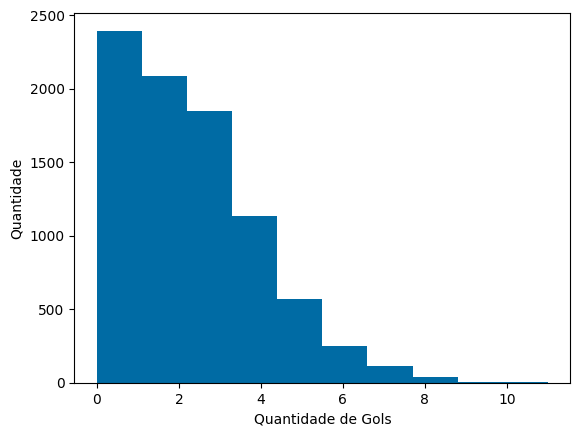

In [8]:
# Histograma da distribuição de gols totais
plt.hist(data=df,
             x="gols_total")
plt.xlabel("Quantidade de Gols")
plt.ylabel("Quantidade")
plt.show()

In [9]:
Q1 = df['gols_total'].quantile(0.25)
Q3 = df['gols_total'].quantile(0.75)
InterQuartil = Q3 - Q1

In [10]:
# Calcule: média, mediana, moda, desvio padrão, IQR
df_medidas = {
    "Média" : round(df["gols_total"].mean(), 3),
    "Mediana" :round(df["gols_total"].median(), 3),
    "Moda" :df['gols_total'].value_counts().idxmax(),
    "Desvio Padrão" :round(df["gols_total"].std(), 2),
    "IQR" :InterQuartil
}
for key, value in df_medidas.items():
    print(f"{key} tem valor: {value}")

Média tem valor: 2.551
Mediana tem valor: 2.0
Moda tem valor: 2.0
Desvio Padrão tem valor: 1.63
IQR tem valor: 3.0


## 2 Mando de campo

<Axes: xlabel='gols_mandante', ylabel='gols_visitante'>

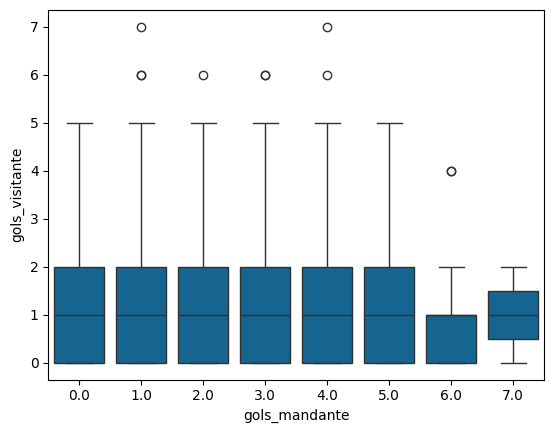

In [11]:
#  Boxplots: gols mandante vs visitante
sns.boxplot(
    data=df,
    x="gols_mandante",
    y="gols_visitante"
)

Identifique e interprete outliers
    
    Analisando este boxplot de uma forma geral, podemos enxergar que a principal quantia de gols geralmente fica entre 0 até 2 gols, indicando que a mioria das partidas ocorrerá isto, porém em poucos casos raros (outliers) podemos vez que o visitante se sobresai, então marcando acima de 2 gols, como 6 e 7 sendo outliers.

In [12]:
# Compare medidas de tendência central

Q1 = df['gols_mandante'].quantile(0.25)
Q3 = df['gols_mandante'].quantile(0.75)
InterQuartilMandante = Q3 - Q1

df_mandante = {
    "Média" : round(df["gols_mandante"].mean(), 3),
    "Mediana" :round(df["gols_mandante"].median(), 3),
    "Moda" :df['gols_mandante'].value_counts().idxmax(),
    "Desvio Padrão" :round(df["gols_mandante"].std(), 2),
    "IQR" :InterQuartilMandante
}

Q1 = df['gols_visitante'].quantile(0.25)
Q3 = df['gols_visitante'].quantile(0.75)
InterQuartilVisitante = Q3 - Q1

df_visitante = {
    "Média" : round(df["gols_visitante"].mean(), 3),
    "Mediana" :round(df["gols_visitante"].median(), 3),
    "Moda" :df['gols_visitante'].value_counts().idxmax(),
    "Desvio Padrão" :round(df["gols_visitante"].std(), 2),
    "IQR" :InterQuartilMandante
}

for key, value in df_mandante.items():
    print(f"Mandante: {key} tem valor: {value}")
    print(f"Visitante: {key} tem valor: {df_visitante[key]}")
    print("----------------------------------------------------")

Mandante: Média tem valor: 1.528
Visitante: Média tem valor: 1.023
----------------------------------------------------
Mandante: Mediana tem valor: 1.0
Visitante: Mediana tem valor: 1.0
----------------------------------------------------
Mandante: Moda tem valor: 1.0
Visitante: Moda tem valor: 0.0
----------------------------------------------------
Mandante: Desvio Padrão tem valor: 1.22
Visitante: Desvio Padrão tem valor: 1.02
----------------------------------------------------
Mandante: IQR tem valor: 1.0
Visitante: IQR tem valor: 1.0
----------------------------------------------------


## 3 Público

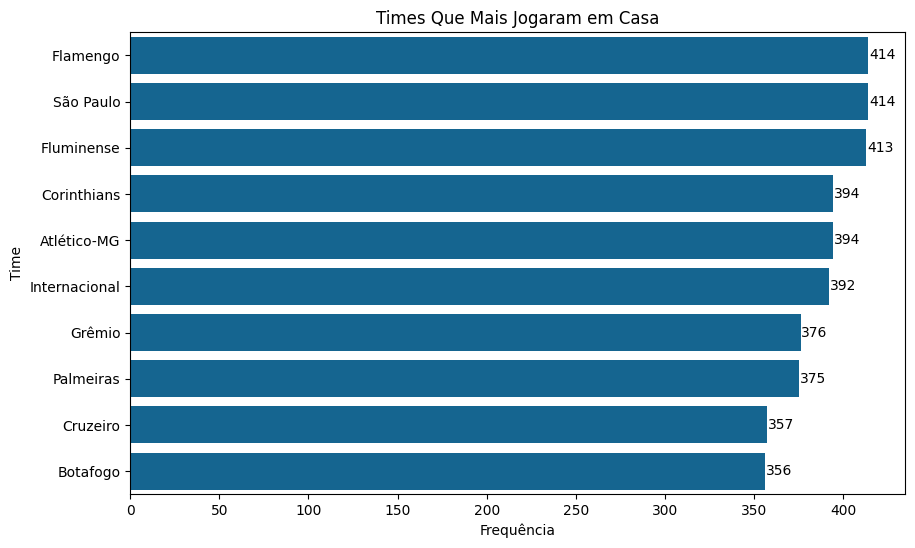

In [13]:
# Gráfico de barras: 10 times que mais jogaram em casa
top10 =df["time_mandante"].value_counts().head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top10.values, y=top10.index)

for i, v in enumerate(top10.values):
    ax.text(v + 0.5, i, str(v), va="center")


plt.title("Times Que Mais Jogaram em Casa")
plt.xlabel("Frequência")
plt.ylabel("Time")
plt.show()

In [14]:
#Estatísticas descritivas do público (dados não-nulos)

In [15]:
df.columns

Index(['ano_campeonato', 'data', 'rodada', 'estadio', 'arbitro', 'publico',
       'publico_max', 'time_mandante', 'time_visitante', 'tecnico_mandante',
       'tecnico_visitante', 'colocacao_mandante', 'colocacao_visitante',
       'valor_equipe_titular_mandante', 'valor_equipe_titular_visitante',
       'idade_media_titular_mandante', 'idade_media_titular_visitante',
       'gols_mandante', 'gols_visitante', 'gols_1_tempo_mandante',
       'gols_1_tempo_visitante', 'escanteios_mandante', 'escanteios_visitante',
       'faltas_mandante', 'faltas_visitante', 'chutes_bola_parada_mandante',
       'chutes_bola_parada_visitante', 'defesas_mandante', 'defesas_visitante',
       'impedimentos_mandante', 'impedimentos_visitante', 'chutes_mandante',
       'chutes_visitante', 'chutes_fora_mandante', 'chutes_fora_visitante',
       'gols_total'],
      dtype='object')

In [16]:
df = df[~df["publico"].isna()]

In [17]:
Q1 = df['publico'].quantile(0.25)
Q3 = df['publico'].quantile(0.75)
InterQuartilPublico = Q3 - Q1

print(f"Média: {round(df["publico"].mean(), 2)} +- {round(df["publico"].std(), 2)}")
print(f"Mediana: {round(df["publico"].median(), 2)}")
print(f"IQR: {InterQuartilPublico}")

Média: 16189.95 +- 14074.41
Mediana: 12685.5
IQR: 17065.0


In [18]:
df["publico"].corr(df["gols_total"])

np.float64(-0.008456328713173712)

**A distribuição de gols é simétrica ou assimétrica? O que isso indica?**
A distribuição dos gols é assimétrica, indicando que não é uma distribuição normal, isso significa que não reproduz de forma fiel caso utilizarmos a medida de tendência central, média. A concentração de gols está inviesada aos menores valores, tendo uma assimetria a direita. 

**Há vantagem numérica do mando de campo**
Analisando a média de uma forma não absoluta (float) percebemos que os times que não visitantes, tem uma tendência maior de marcar mais gols, mesmo que não seja por um número exato, mesmo levando em consideração o desvio padrão no cálculo.

**Qual a relação entre público e gols**
Não existe nada que mostre fortemente uma correlação direta entre ambos, mas o que pode-se enxergar é que quanto maior a quantidade de gols, menor a quantidade de público.

# 1.2 Teste de Hipótese

## 1 As hipóteses

* $H_0: \mu_{mandante} = \mu_{visitante}$ (sem diferença)
* $H_1: \mu_{mandante} > \mu_{visitante}$ (mandantes marcam mais)

# 2 Execute teste t

In [19]:
stat, p_value = stats.ttest_ind(df["gols_mandante"], df["gols_visitante"])
print(stat, p_value)

25.929445806869563 1.0611942764573151e-144


Assumindo um α = 0.005, vemos que o p-value acaba por rejeitar $H_0$ mostrando sim que há uma diferença entre os gols marcados pelo time de casa vs. time visitante. Para saber disso analisamos a variável stat, por conta dela ser positiva, verificamos que há uma tendência do time mandante marcar mais gols que o time visitante quando analisada a média.

## 3 Análise Resultados

In [20]:
df_analise = {}
df_analise["Média"] = df_mandante["Média"]
df_analise["Desvio Padrão"] = df_mandante["Desvio Padrão"]

for key, value in df_analise.items():
    print(f"Mandante: {key} tem valor: {value}")
    print(f"Visitante: {key} tem valor: {df_visitante[key]}")
    print("----------------------------------------------------")

Mandante: Média tem valor: 1.528
Visitante: Média tem valor: 1.023
----------------------------------------------------
Mandante: Desvio Padrão tem valor: 1.22
Visitante: Desvio Padrão tem valor: 1.02
----------------------------------------------------


### Tamanho do efeito (diferença das médias)
Verificando as estatísticas, vemos que a média de gols do time mandante é maior que a do time visitante, mesmo levando em consideração o desvio padrão pode-se enxergar uma tendência de que o time mandante marca 1.5 vezes a mais que o visitante.

### Significância estatística vs. Revelevância prática
O valor retornado por este teste t, indica uma forte diferença entre a quantidade de gols marcados pelo time mandante e o time visitante, porém não indica a magnitude, portanto não posso afirmar que ele possui 25x mais chance de algo. E esse valor se confirma ao analisarmos a média de gols de cada um. Então há uma relação, porém não uma direta.

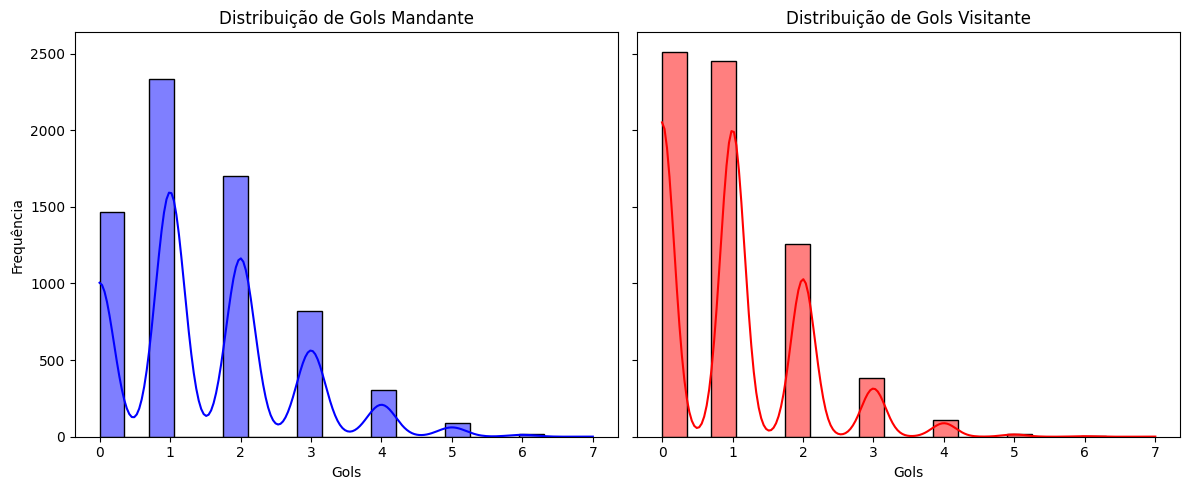

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.histplot(df["gols_mandante"], bins=20, kde=True, ax=axes[0], color="blue")
axes[0].set_title("Distribuição de Gols Mandante")
axes[0].set_xlabel("Gols")
axes[0].set_ylabel("Frequência")

sns.histplot(df["gols_visitante"], bins=20, kde=True, ax=axes[1], color="red")
axes[1].set_title("Distribuição de Gols Visitante")
axes[1].set_xlabel("Gols")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### O valor-p permite rejeitar $H_0$?
Sim! mesmo que o valor alfa fosse bem menor, ainda seria possível rejeitar a hipótese nula

### Qual a diferença prática em gols?
Ela corrobora com a hipótese selecionada, pois com os dados deste dataset, verifica-se que os times mandantes tem uma taxa maior de gols, mesmo que sejam por casas decimais, mas isso indica que de uma forma inteira, eles marcam mais.

### O resultado é significativo E relevante?
Sim! O resultado é significativo e relevante, pois ao verificar que esta hipótese aponta para que haja realmente uma diferença, e verificando os dados, analisando a medida central média, verificamos que há uma maior taxa de gols pelos times mandantes

# 1.3 Investigação Livre + Pitch

In [22]:
df.head()

,ano_campeonato,data,rodada,estadio,arbitro,publico,publico_max,time_mandante,time_visitante,tecnico_mandante,...,chutes_bola_parada_visitante,defesas_mandante,defesas_visitante,impedimentos_mandante,impedimentos_visitante,chutes_mandante,chutes_visitante,chutes_fora_mandante,chutes_fora_visitante,gols_total
418,2016,2016-09-15,25,Estádio Olímpico Nilton Santos,Paulo Henrique Schleinch Vollkopf,11883.0,46931.0,Botafogo,Santos FC,Jair Ventura,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
419,2016,2016-09-25,27,Estádio Estadual Kléber José de Andrade,Leandro Pedro Vuaden,13780.0,NaN,Flamengo,Cruzeiro,Zé Ricardo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
420,2016,2016-10-09,29,Estádio Municipal Paulo Machado de Carvalho,Ricardo Marques Ribeiro,21773.0,78838.0,Flamengo,Santa Cruz,Zé Ricardo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
421,2016,2016-10-23,32,Estádio Jornalista Mário Filho,Anderson Daronco,54250.0,78838.0,Flamengo,Corinthians,Zé Ricardo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
422,2016,2016-10-13,30,Estádio General Sílvio Raulino de Oliveira,Sandro Ricci,9008.0,NaN,Fluminense,Flamengo,Levir Culpi,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0


In [23]:
df.columns

Index(['ano_campeonato', 'data', 'rodada', 'estadio', 'arbitro', 'publico',
       'publico_max', 'time_mandante', 'time_visitante', 'tecnico_mandante',
       'tecnico_visitante', 'colocacao_mandante', 'colocacao_visitante',
       'valor_equipe_titular_mandante', 'valor_equipe_titular_visitante',
       'idade_media_titular_mandante', 'idade_media_titular_visitante',
       'gols_mandante', 'gols_visitante', 'gols_1_tempo_mandante',
       'gols_1_tempo_visitante', 'escanteios_mandante', 'escanteios_visitante',
       'faltas_mandante', 'faltas_visitante', 'chutes_bola_parada_mandante',
       'chutes_bola_parada_visitante', 'defesas_mandante', 'defesas_visitante',
       'impedimentos_mandante', 'impedimentos_visitante', 'chutes_mandante',
       'chutes_visitante', 'chutes_fora_mandante', 'chutes_fora_visitante',
       'gols_total'],
      dtype='object')

In [24]:
#Existe algum impacto em relação aos impedimentos? e a diferença de colocação entre o mandante e o visitante?

In [25]:
df["impedimentos_total"] = df["impedimentos_visitante"] + df["impedimentos_mandante"]
df["diferenca_colocacao"] = np.abs(df["colocacao_visitante"] - df["colocacao_mandante"]).astype("int")

In [27]:
def find_winner(df):
    conditions = [
        df["gols_mandante"] > df["gols_visitante"],
        df["gols_mandante"] < df["gols_visitante"],
    ]
    choices = ["Mandante", "Visitante"]
    df["vencedor_partida"] = np.select(conditions, choices, default="Empate")
    return df

In [28]:
df = find_winner(df)

In [37]:
faixas_dif_coloc = [1, 3, 5, 10, np.inf]
labels= ["1 - 3", "3 - 5", "5 - 10", "10+"]

In [38]:
df["bins_coloc"] = pd.cut(df["diferenca_colocacao"], bins=faixas_dif_coloc, labels=labels)

In [39]:
df["bins_coloc"]

418      3 - 5
419        10+
420        10+
421      3 - 5
422      1 - 3
         ...  
8448    5 - 10
8449    5 - 10
8450       10+
8451     3 - 5
8452    5 - 10
Name: bins_coloc, Length: 6742, dtype: category
Categories (4, object): ['1 - 3' < '3 - 5' < '5 - 10' < '10+']

<Axes: xlabel='vencedor_partida', ylabel='impedimentos_total'>

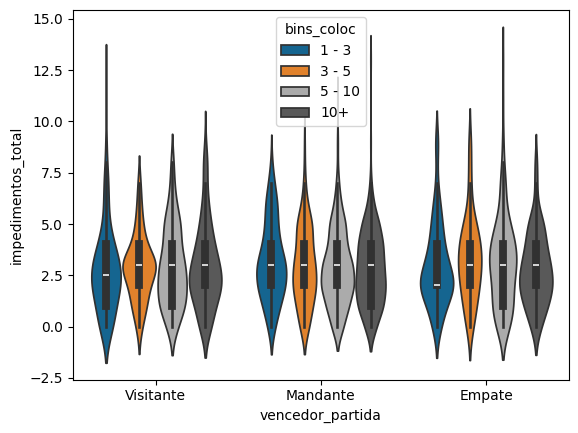

In [40]:
sns.violinplot(
    data=df,
    x="vencedor_partida",
    y="impedimentos_total",
    hue="bins_coloc"

)

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

In [ ]:
numeric_df.columns

In [ ]:
numeric_df["diferenca_colocacao"].head()

In [ ]:
numeric_df[["diferenca_colocacao", "impedimentos_total"]].describe()

In [ ]:
df

In [ ]:
sns.regplot(
    data=numeric_df,
    x="diferenca_colocacao",
    y="impedimentos_total"
)
plt.show()